In [1]:
import torch
import torchvision.transforms as transforms

In [29]:
import torch
import torch.nn as nn

class MyModule(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(in_features, out_features, bias=False),
            nn.Sequential(
                nn.Conv1d(in_channels=out_features, out_channels=out_features,
                          kernel_size=3),
                nn.BatchNorm1d(out_features)
            )
        )
        # print('a initial:\n', self.a.weight)
        # Register a hook on self.a
        # self.a.weight.register_hook(self.update_a)

    def forward(self, x):
        # print('FORWARD self.a:\n', self.a.weight)
        return self.a(x)

    def update_a(self, grad):
        # Define the update logic for self.a
        # You can modify self.a based on the gradients or any other logic
        # self.a = self.a + 0.1 * grad  # Example update logic
        print('\nHOOK A')
        # print('self.a:\n', self.a.weight)
        # with torch.no_grad():
        #     self.a.weight.add_(0.01)
        # print('self.a:\n', self.a.weight)
        

# Example usage
model = MyModule(2, 2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


def loop_over_sequence(seq):
    print('\nLOOP OVER SEQUENCE')
    for elem in seq:
        print(type(elem))
        if type(elem) == nn.Sequential:
            loop_over_sequence(elem)

loop_over_sequence(model.seq)


x = torch.randn(10, 2)
target = x * (2. + -3*x)
compute_loss = nn.MSELoss()
num_epochs = 3

if False:
    model.train()
    # Training loop
    for _ in range(num_epochs):
        optimizer.zero_grad()
        output = model(x)

        print('\nloss')
        loss = compute_loss(output, target)
        print('loss.backward')
        print(model.a.weight)
        loss.backward()
        print('optimizer.step')
        print(model.a.weight)
        optimizer.step()
        print('end of iter')
        print(model.a.weight)

        # The update_a function will be automatically called after optimizer.step()
        # You can access the updated value of self.a here
        # updated_a = model.a



LOOP OVER SEQUENCE
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.container.Sequential'>

LOOP OVER SEQUENCE
<class 'torch.nn.modules.conv.Conv1d'>
<class 'torch.nn.modules.batchnorm.BatchNorm1d'>


In [100]:
import torch
import numpy as np
t = torch.arange(48, dtype=float).reshape(2,2,3,4)
for i in range(4):
    a = np.arange( 12*(i), 12*(i+1))
    print(a.sum(), a.mean(), ((a-a.mean())**2).sum())
    

def center_tensor2d(t):
    t.add_(-t.mean((-1,-2)).reshape(t.shape[:-2] + (1,1)))


def normalize_centered_tensor(t):
    t.mul_((1./torch.sqrt((t*t).sum((-1, -2)))).reshape(t.shape[:-2]+(1, 1)))

print(t)
print(t.sum())
# print(t.mean((-1,-2)), t.mean((-1,-2)).shape)
center_tensor2d(t)
# print(t.mean((-1,-2)), t.mean((-1,-2)).shape)

print((t*t).sum((-1, -2)))
normalize_centered_tensor(t)
print((t*t).sum((-1, -2)))

66 5.5 143.0
210 17.5 143.0
354 29.5 143.0
498 41.5 143.0
tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.]],

         [[12., 13., 14., 15.],
          [16., 17., 18., 19.],
          [20., 21., 22., 23.]]],


        [[[24., 25., 26., 27.],
          [28., 29., 30., 31.],
          [32., 33., 34., 35.]],

         [[36., 37., 38., 39.],
          [40., 41., 42., 43.],
          [44., 45., 46., 47.]]]], dtype=torch.float64)
tensor(1128., dtype=torch.float64)
tensor([[143., 143.],
        [143., 143.]], dtype=torch.float64)
tensor([[1., 1.],
        [1., 1.]], dtype=torch.float64)


tensor(-0.9997)
tensor(-0.0027)
tensor(-0.0027)


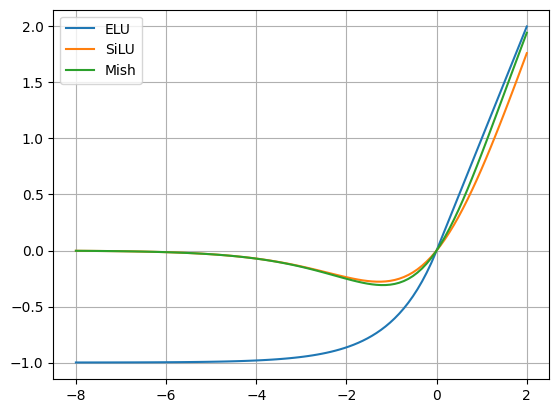

In [94]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

x = torch.linspace(-8, 2, 100)

fig, ax = plt.subplots()
for (func, label) in [(nn.ELU(), 'ELU'),
                      (nn.SiLU(), 'SiLU'),
                      (nn.Mish(), 'Mish'),
                      ]:
    y = func(x)
    ax.plot(x.numpy(), y.numpy(), label=label)
    print(y[0])
ax.grid(visible=True)
ax.legend()

In [107]:
import numpy as np

a = np.random.random(30)
seek = ( (a-a.mean())**2 ).sum()
print( seek )
print()
print( '1:', (a*a).sum() )
# print( a.mean()**2 )
print( '2:', a.sum()**2 / 30 )
print( '3:', (a*a).mean() )
val = (a*a).sum() - a.sum()**2 / a.size
print( val )
print()
print(val-seek)

2.5191687406383023

1: 7.2847973329341755
2: 4.765628592295873
3: 0.24282657776447253
2.5191687406383023

0.0


In [41]:
import numpy as np

a = np.random.random(3)
b = np.random.random(3)
print('a:', a, a.mean(), (a*a).sum())
print('b:', b, b.mean(), (b*b).sum())

a -= a.mean()
b -= b.mean()

a /= np.sqrt((a*a).sum())
b /= np.sqrt((b*b).sum())

c = np.convolve(a, b)
print('c:', c, c.mean(), (c*c).sum())

a /= np.sqrt((c*c).sum())
c = np.convolve(a, b)


a_avg, a2_s = a.mean(), (a*a).sum()
b_avg, b2_s = b.mean(), (b*b).sum()
c_avg, c2_s = c.mean(), (c*c).sum()

print()
print('a:', a_avg, a2_s)
print('b:', b_avg, b2_s)
print('c:', c_avg, c2_s)


a: [0.07604475 0.28371223 0.13077338] 0.16351012280722177 0.10337711328708993
b: [0.4975632  0.14442633 0.67072675] 0.43757209194142277 0.718302476046957
c: [-0.09087279  0.56893361 -0.99743635  0.65156305 -0.13218751] -1.6653345369377347e-17 1.768830544285955

a: 9.25185853854297e-18 0.5653452803777096
b: 1.1102230246251565e-16 1.0
c: -5.551115123125783e-18 0.9999999999999999


In [45]:
torch.range(0, 10)

/tmp/ipykernel_48664/1549641488.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  torch.range(0, 10)


tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [53]:
m = nn.AvgPool2d(3, stride=1)
x = torch.arange(0, 18).reshape(2,3,3)
print(x)
y = m(x)
print(y)
m = nn.AvgPool2d(3, stride=1, divisor_override=1)
y = m(x)
print(y)

print(x.sum((-1,-2)))

tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]]])
tensor([[[ 4]],

        [[13]]])
tensor([[[ 36]],

        [[117]]])
tensor([ 36, 117])


In [46]:
kernel_size = 7
sigma = 3./3
gaussianBlur = transforms.GaussianBlur(kernel_size, sigma)
image = torch.zeros((1, kernel_size,kernel_size), dtype=torch.float)
image[0, kernel_size//2, kernel_size//2] = 1.

# image
gaussianBlur(image).numpy().round(3)

array([[[0.   , 0.   , 0.002, 0.004, 0.002, 0.   , 0.   ],
        [0.   , 0.003, 0.013, 0.022, 0.013, 0.003, 0.   ],
        [0.002, 0.013, 0.059, 0.097, 0.059, 0.013, 0.002],
        [0.004, 0.022, 0.097, 0.159, 0.097, 0.022, 0.004],
        [0.002, 0.013, 0.059, 0.097, 0.059, 0.013, 0.002],
        [0.   , 0.003, 0.013, 0.022, 0.013, 0.003, 0.   ],
        [0.   , 0.   , 0.002, 0.004, 0.002, 0.   , 0.   ]]], dtype=float32)

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def visualize_gaussian_kernel(kernel_size, sigma):
    # Create a 2D Gaussian kernel
    kernel = torch.zeros((kernel_size, kernel_size))
    center = kernel_size // 2

    for i in range(kernel_size):
        for j in range(kernel_size):
            x = i - center
            y = j - center
            kernel[i, j] = torch.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    
    # Normalize the kernel
    kernel = kernel / kernel.sum()

    # Convert the kernel tensor to a numpy array for visualization
    kernel_np = kernel.numpy()

    # Display the kernel using a heatmap
    plt.imshow(kernel_np, cmap='hot', interpolation='nearest')
    plt.title('Gaussian Blur Kernel')
    plt.colorbar()
    plt.show()

# Example usage
kernel_size = 5
sigma = 1.0
visualize_gaussian_kernel(kernel_size, sigma)

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.device_count()

1

In [4]:
torch.cuda.current_device()

0

In [5]:
torch.cuda.device(0)

In [6]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3070 Laptop GPU'